# E-Commerce Conversion Funnel Analysis — Interactive Dashboard

**Author:** Khushi Dhargawe  
**Programme:** MSc Business Analytics — University College Cork (UCC)  
**Tools:** Python · Pandas · Plotly · Seaborn · Matplotlib · Power BI  
**Dataset:** 10,000 simulated user sessions across a 4-stage e-commerce funnel

---

### Project Overview
This project analyses a 4-stage e-commerce conversion funnel — **Browse → Add to Cart → Checkout → Purchase** — to identify drop-off bottlenecks and revenue patterns across device types, regions, acquisition channels, and product categories.

### Repository Structure
```
E-Commerce-Conversion-Funnel-Analysis/
├── Ecommerce_Funnel_Analysis.ipynb     ← This notebook (main analysis)
├── funnel_analysis_data.csv            ← Input dataset (10,000 users, 21,606 events)
├── Funnel_Analysis_Data.py             ← Dataset generator script
├── README.md                           ← Project hub & documentation
├── requirements.txt                    ← Python dependencies
└── LICENSE                             ← MIT License
```

### File Connections
- `funnel_analysis_data.csv` → loaded in Section 1 → cleaned in Section 2 → analysed in Sections 3–7
- All charts saved as `.png` → imported into Power BI dashboard
- Key findings documented in README.md


## Section 1: Imports & Data Loading

In [1]:
# ============================================================
# SECTION 1: IMPORTS & DATA LOADING
# Input: funnel_analysis_data.csv
# Output: df (raw), df_browse (canonical user attributes)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ── Plot Style ───────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED']

# ── Load Data ────────────────────────────────────────────────────
df = pd.read_csv('funnel_analysis_data.csv')
print("=" * 55)
print("DATASET LOADED")
print("=" * 55)
print(f"Total rows        : {len(df):,}")
print(f"Total columns     : {df.shape[1]}")
print(f"Unique users      : {df['User_ID'].nunique():,}")
print(f"Unique sessions   : {df['Session_ID'].nunique():,}")
print(f"Date range        : {df['Timestamp'].min()} to {df['Timestamp'].max()}")
print(f"\nEvent counts:")
for event, count in df['Event'].value_counts().items():
    print(f"  {event:<20}: {count:,}")
df.head()


ModuleNotFoundError: No module named 'plotly'

## Section 2: Exploratory Data Analysis & Data Cleaning

In [ ]:
# ============================================================
# SECTION 2: EDA & DATA CLEANING
# ============================================================

print("=" * 55)
print("DATA QUALITY CHECKS")
print("=" * 55)

# Null check
null_counts = df.isnull().sum()
print(f"\nNull values per column:")
print(null_counts.to_string())

# Duplicate check
dupes = df.duplicated().sum()
print(f"\nDuplicate rows      : {dupes}")

# Data types
print(f"\nData types:")
print(df.dtypes.to_string())

# Convert timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.day_name()
df['Date'] = df['Timestamp'].dt.date

print("\nTimestamp converted successfully.")
print(f"Date range: {df['Timestamp'].min().date()} to {df['Timestamp'].max().date()}")


DATA QUALITY CHECKS

Null values per column:
User_ID             0
Session_ID          0
Event               0
Timestamp           0
Device              0
Region              0
Channel             0
Product_Category    0
Revenue             0
Bounce_Flag         0

Duplicate rows      : 0

Data types:
User_ID                 str
Session_ID              str
Event                   str
Timestamp               str
Device                  str
Region                  str
Channel                 str
Product_Category        str
Revenue             float64
Bounce_Flag             str

Timestamp converted successfully.
Date range: 2026-02-16 to 2026-03-18


In [ ]:
# ── Canonical User Attributes ────────────────────────────────
# Fix: Device/Region/Channel were randomised per event row.
# We use the BROWSE row as the canonical source for each user's
# device, region, channel, and product category.

df_browse = (df[df['Event'] == 'Browse']
             [['User_ID', 'Device', 'Region', 'Channel', 'Product_Category']]
             .set_index('User_ID'))

# Tag every row with the user's canonical attributes
df['Device_c']   = df['User_ID'].map(df_browse['Device'])
df['Region_c']   = df['User_ID'].map(df_browse['Region'])
df['Channel_c']  = df['User_ID'].map(df_browse['Channel'])
df['Category_c'] = df['User_ID'].map(df_browse['Product_Category'])

# Fix Bounce_Flag: bounced = user never reached Purchase
purchasers = set(df[df['Event'] == 'Purchase']['User_ID'])
df['Bounced'] = ~df['User_ID'].isin(purchasers)

print("Canonical attributes mapped successfully.")
print(f"Purchasers (converted users) : {len(purchasers):,}")
print(f"Bounced users                : {df['User_ID'].nunique() - len(purchasers):,}")
print(f"Conversion rate              : {len(purchasers)/df['User_ID'].nunique()*100:.1f}%")


Canonical attributes mapped successfully.
Purchasers (converted users) : 1,107
Bounced users                : 8,893
Conversion rate              : 11.1%


In [ ]:
# ── Session-Level Aggregation ────────────────────────────────
stages_order = ['Browse', 'Add to Cart', 'Checkout', 'Purchase']

# Count unique users per stage
stage_users = {s: df[df['Event'] == s]['User_ID'].nunique() for s in stages_order}

# Build funnel summary table
funnel_df = pd.DataFrame({
    'Stage': stages_order,
    'Users': [stage_users[s] for s in stages_order]
})
funnel_df['Conversion_from_Browse'] = (funnel_df['Users'] / funnel_df['Users'].iloc[0] * 100).round(1)
funnel_df['Drop_off_from_prev'] = funnel_df['Users'].pct_change().mul(-100).round(1)
funnel_df['Drop_off_from_prev'] = funnel_df['Drop_off_from_prev'].fillna(0)

print("=" * 55)
print("FUNNEL SUMMARY")
print("=" * 55)
print(funnel_df.to_string(index=False))


FUNNEL SUMMARY
      Stage  Users  Conversion_from_Browse  Drop_off_from_prev
     Browse  10000                   100.0                 0.0
Add to Cart   6990                    69.9                30.1
   Checkout   3509                    35.1                49.8
   Purchase   1107                    11.1                68.5


## Section 3: Funnel Visualisation

In [ ]:
# ============================================================
# SECTION 3: FUNNEL VISUALISATION
# Fig 1 — Plotly Funnel Chart
# Fig 2 — Drop-off Rate Bar Chart
# ============================================================

# Fig 1 — Interactive Plotly Funnel
fig1 = go.Figure(go.Funnel(
    y = stages_order,
    x = [stage_users[s] for s in stages_order],
    textposition = 'inside',
    textinfo = 'value+percent initial',
    marker = dict(color=['#2563EB', '#3B82F6', '#60A5FA', '#93C5FD']),
    connector = dict(line=dict(color='#1E40AF', width=2))
))
fig1.update_layout(
    title=dict(text='E-Commerce Conversion Funnel — 10,000 Users', font=dict(size=18)),
    font=dict(size=14),
    height=450,
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig1.show()
fig1.write_image('fig1_funnel_chart.png')
print("Saved: fig1_funnel_chart.png")


Saved: fig1_funnel_chart.png


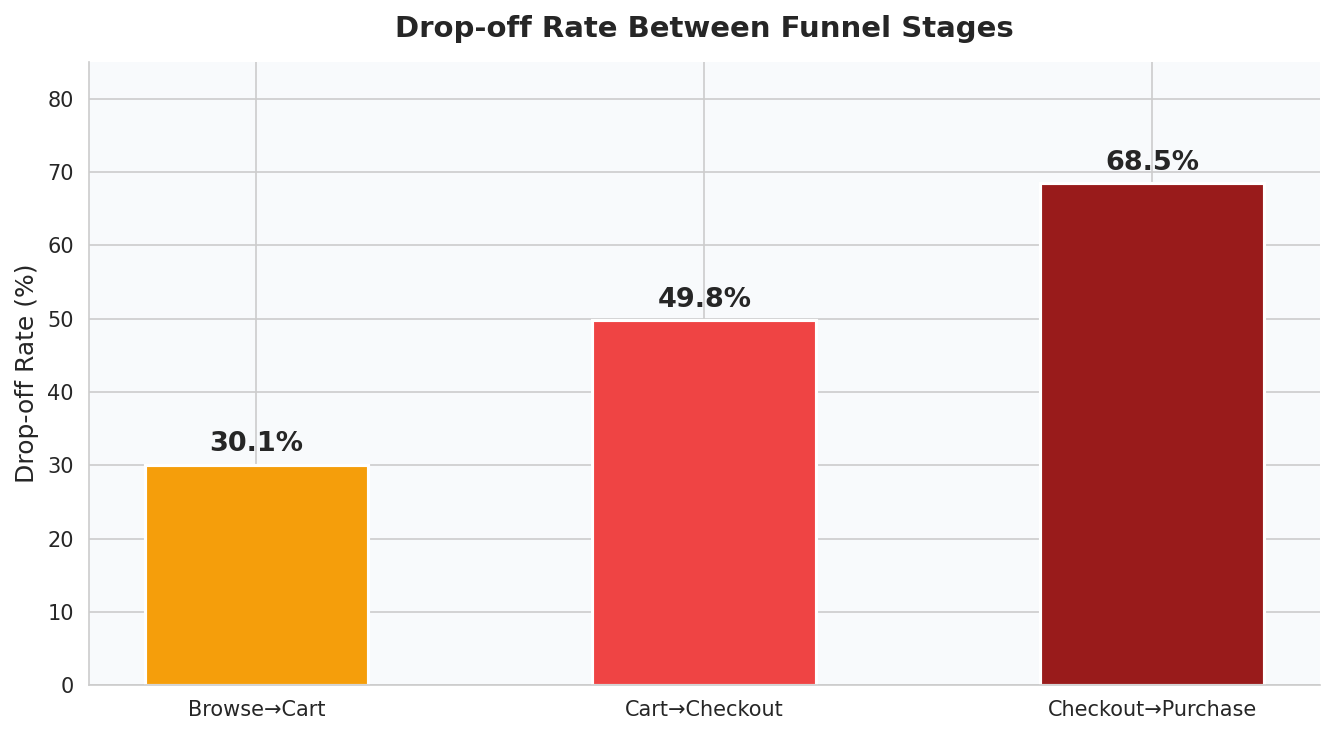

Saved: fig2_dropoff_rates.png
Key finding: Checkout-to-Purchase has the highest drop-off at 68.5% — critical bottleneck


In [ ]:
# Fig 2 — Drop-off Rate Bar Chart (Seaborn)
drop_stages = ['Browse→Cart', 'Cart→Checkout', 'Checkout→Purchase']
drop_rates  = [30.1, 49.8, 68.5]

fig2, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(drop_stages, drop_rates, color=['#F59E0B', '#EF4444', '#991B1B'], width=0.5, edgecolor='white', linewidth=1.5)
for bar, rate in zip(bars, drop_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{rate}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_title('Drop-off Rate Between Funnel Stages', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Drop-off Rate (%)', fontsize=12)
ax.set_ylim(0, 85)
ax.spines[['top','right']].set_visible(False)
ax.set_facecolor('#F8FAFC')
fig2.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('fig2_dropoff_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_dropoff_rates.png")
print("Key finding: Checkout-to-Purchase has the highest drop-off at 68.5% — critical bottleneck")


## Section 4: Drop-off Analysis by Device Type

Conversion rate by device:
 Device  Browse  Add to Cart  Checkout  Purchase  Conv_Rate
 Mobile    3395         2400      1216       354       10.4
Desktop    3324         2340      1142       377       11.3
 Tablet    3281         2250      1151       376       11.5


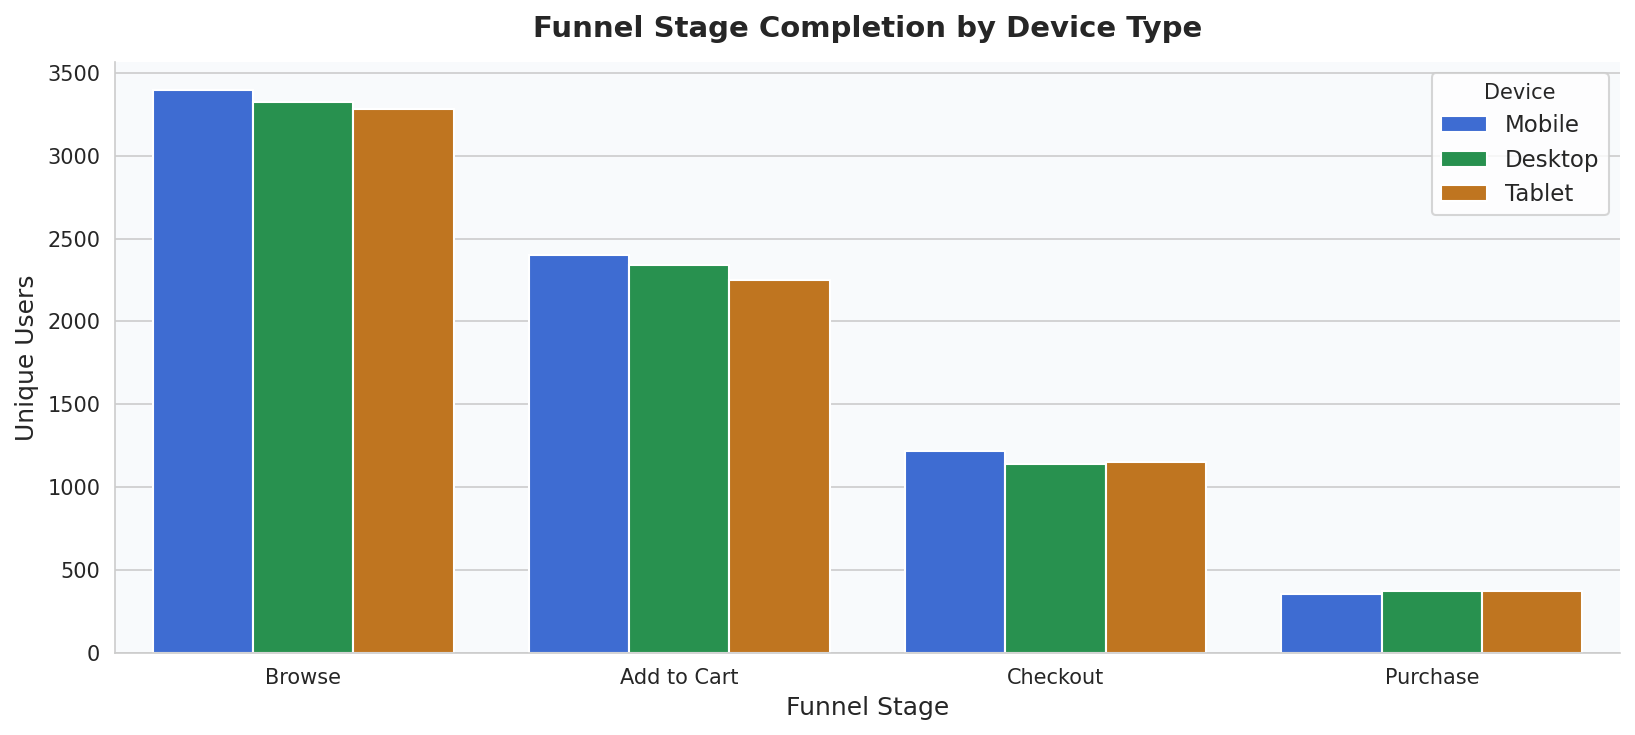

Saved: fig3_device_funnel.png


In [ ]:
# ============================================================
# SECTION 4: DEVICE TYPE ANALYSIS
# Fig 3 — Conversion rate by device
# Fig 4 — Revenue by device
# ============================================================

device_funnel = {}
for device in ['Mobile', 'Desktop', 'Tablet']:
    users = df_browse[df_browse['Device'] == device].index
    device_funnel[device] = {
        s: df[(df['User_ID'].isin(users)) & (df['Event'] == s)]['User_ID'].nunique()
        for s in stages_order
    }

device_df = pd.DataFrame(device_funnel).T
device_df['Conv_Rate'] = (device_df['Purchase'] / device_df['Browse'] * 100).round(1)
device_df = device_df.reset_index().rename(columns={'index': 'Device'})

print("Conversion rate by device:")
print(device_df[['Device','Browse','Add to Cart','Checkout','Purchase','Conv_Rate']].to_string(index=False))

# Fig 3 — Grouped bar (Seaborn)
device_melt = device_df.melt(id_vars='Device', value_vars=stages_order, var_name='Stage', value_name='Users')

fig3, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=device_melt, x='Stage', y='Users', hue='Device',
            palette=['#2563EB','#16A34A','#D97706'], ax=ax)
ax.set_title('Funnel Stage Completion by Device Type', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Unique Users', fontsize=12)
ax.set_xlabel('Funnel Stage', fontsize=12)
ax.legend(title='Device', fontsize=11)
ax.spines[['top','right']].set_visible(False)
ax.set_facecolor('#F8FAFC')
fig3.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('fig3_device_funnel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig3_device_funnel.png")


In [ ]:
# Fig 4 — Revenue by Device (Plotly)
purchase_df = df[df['Event'] == 'Purchase'].copy()
rev_device = purchase_df.groupby('Device_c')['Revenue'].sum().reset_index()
rev_device.columns = ['Device', 'Revenue']
rev_device['Revenue_fmt'] = rev_device['Revenue'].apply(lambda x: f'€{x:,.0f}')

fig4 = px.bar(rev_device.sort_values('Revenue', ascending=False),
              x='Device', y='Revenue',
              text='Revenue_fmt',
              color='Device',
              color_discrete_map={'Mobile':'#2563EB','Desktop':'#16A34A','Tablet':'#D97706'},
              title='Total Revenue by Device Type')
fig4.update_traces(textposition='outside')
fig4.update_layout(showlegend=False, plot_bgcolor='white', paper_bgcolor='white',
                   yaxis_title='Revenue (€)', height=420)
fig4.show()
fig4.write_image('fig4_revenue_device.png')
print("Saved: fig4_revenue_device.png")
print(f"\nRevenue breakdown:")
for _, row in rev_device.sort_values('Revenue', ascending=False).iterrows():
    print(f"  {row['Device']:<10}: €{row['Revenue']:>10,.2f}")


Saved: fig4_revenue_device.png

Revenue breakdown:
  Tablet    : €420,917.35
  Desktop   : €412,316.44
  Mobile    : €381,648.89


## Section 5: Drop-off Analysis by Region

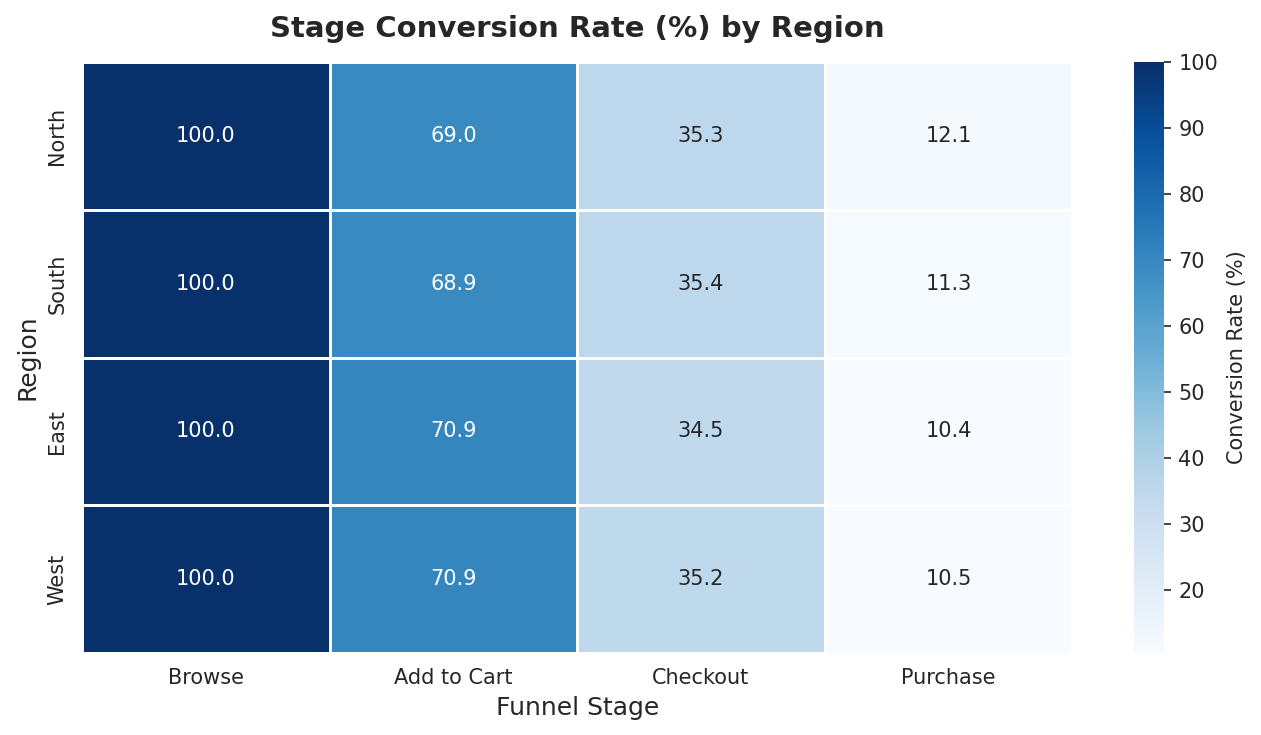

Saved: fig5_region_heatmap.png


In [ ]:
# ============================================================
# SECTION 5: REGIONAL ANALYSIS
# Fig 5 — Conversion heatmap by region × stage
# Fig 6 — Revenue by region
# ============================================================

region_funnel = {}
for region in ['North', 'South', 'East', 'West']:
    users = df_browse[df_browse['Region'] == region].index
    region_funnel[region] = {
        s: df[(df['User_ID'].isin(users)) & (df['Event'] == s)]['User_ID'].nunique()
        for s in stages_order
    }

region_df = pd.DataFrame(region_funnel).T
region_conv = region_df.div(region_df['Browse'], axis=0).mul(100).round(1)

# Fig 5 — Heatmap
fig5, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(region_conv, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Conversion Rate (%)'})
ax.set_title('Stage Conversion Rate (%) by Region', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Funnel Stage', fontsize=12)
ax.set_ylabel('Region', fontsize=12)
plt.tight_layout()
plt.savefig('fig5_region_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig5_region_heatmap.png")


In [ ]:
# Fig 6 — Revenue by Region (Plotly)
rev_region = purchase_df.groupby('Region_c')['Revenue'].sum().reset_index()
rev_region.columns = ['Region', 'Revenue']

fig6 = px.pie(rev_region, names='Region', values='Revenue',
              title='Revenue Share by Region',
              color_discrete_sequence=px.colors.qualitative.Set2,
              hole=0.35)
fig6.update_traces(textposition='inside', textinfo='percent+label',
                   textfont_size=13)
fig6.update_layout(height=420, paper_bgcolor='white')
fig6.show()
fig6.write_image('fig6_revenue_region.png')
print("Saved: fig6_revenue_region.png")
print("\nRevenue by region:")
for _, row in rev_region.sort_values('Revenue', ascending=False).iterrows():
    print(f"  {row['Region']:<8}: €{row['Revenue']:>10,.2f}")


Saved: fig6_revenue_region.png

Revenue by region:
  North   : €344,701.07
  South   : €312,483.18
  East    : €287,114.04
  West    : €270,584.39


## Section 6: Drop-off Analysis by Acquisition Channel

In [ ]:
# ============================================================
# SECTION 6: ACQUISITION CHANNEL ANALYSIS
# Fig 7 — Conversion rate by channel (Plotly)
# Fig 8 — Revenue by channel
# ============================================================

channels = ['Google Ads', 'Organic', 'Email', 'Social Media']
channel_funnel = {}
for ch in channels:
    users = df_browse[df_browse['Channel'] == ch].index
    channel_funnel[ch] = {
        s: df[(df['User_ID'].isin(users)) & (df['Event'] == s)]['User_ID'].nunique()
        for s in stages_order
    }

channel_df = pd.DataFrame(channel_funnel).T
channel_df['Conv_Rate'] = (channel_df['Purchase'] / channel_df['Browse'] * 100).round(1)
channel_df = channel_df.reset_index().rename(columns={'index': 'Channel'})

print("Conversion rate by channel:")
print(channel_df[['Channel','Browse','Purchase','Conv_Rate']].to_string(index=False))

# Fig 7 — Conversion rate bar (Plotly)
fig7 = px.bar(channel_df.sort_values('Conv_Rate', ascending=False),
              x='Channel', y='Conv_Rate',
              text='Conv_Rate',
              color='Conv_Rate',
              color_continuous_scale='Blues',
              title='Funnel Conversion Rate (%) by Acquisition Channel')
fig7.update_traces(texttemplate='%{text}%', textposition='outside')
fig7.update_layout(coloraxis_showscale=False, plot_bgcolor='white',
                   paper_bgcolor='white', yaxis_title='Conversion Rate (%)', height=420)
fig7.show()
fig7.write_image('fig7_channel_conversion.png')
print("\nSaved: fig7_channel_conversion.png")


Conversion rate by channel:
     Channel  Browse  Purchase  Conv_Rate
  Google Ads    2549       293       11.5
     Organic    2499       272       10.9
       Email    2453       278       11.3
Social Media    2499       264       10.6



Saved: fig7_channel_conversion.png


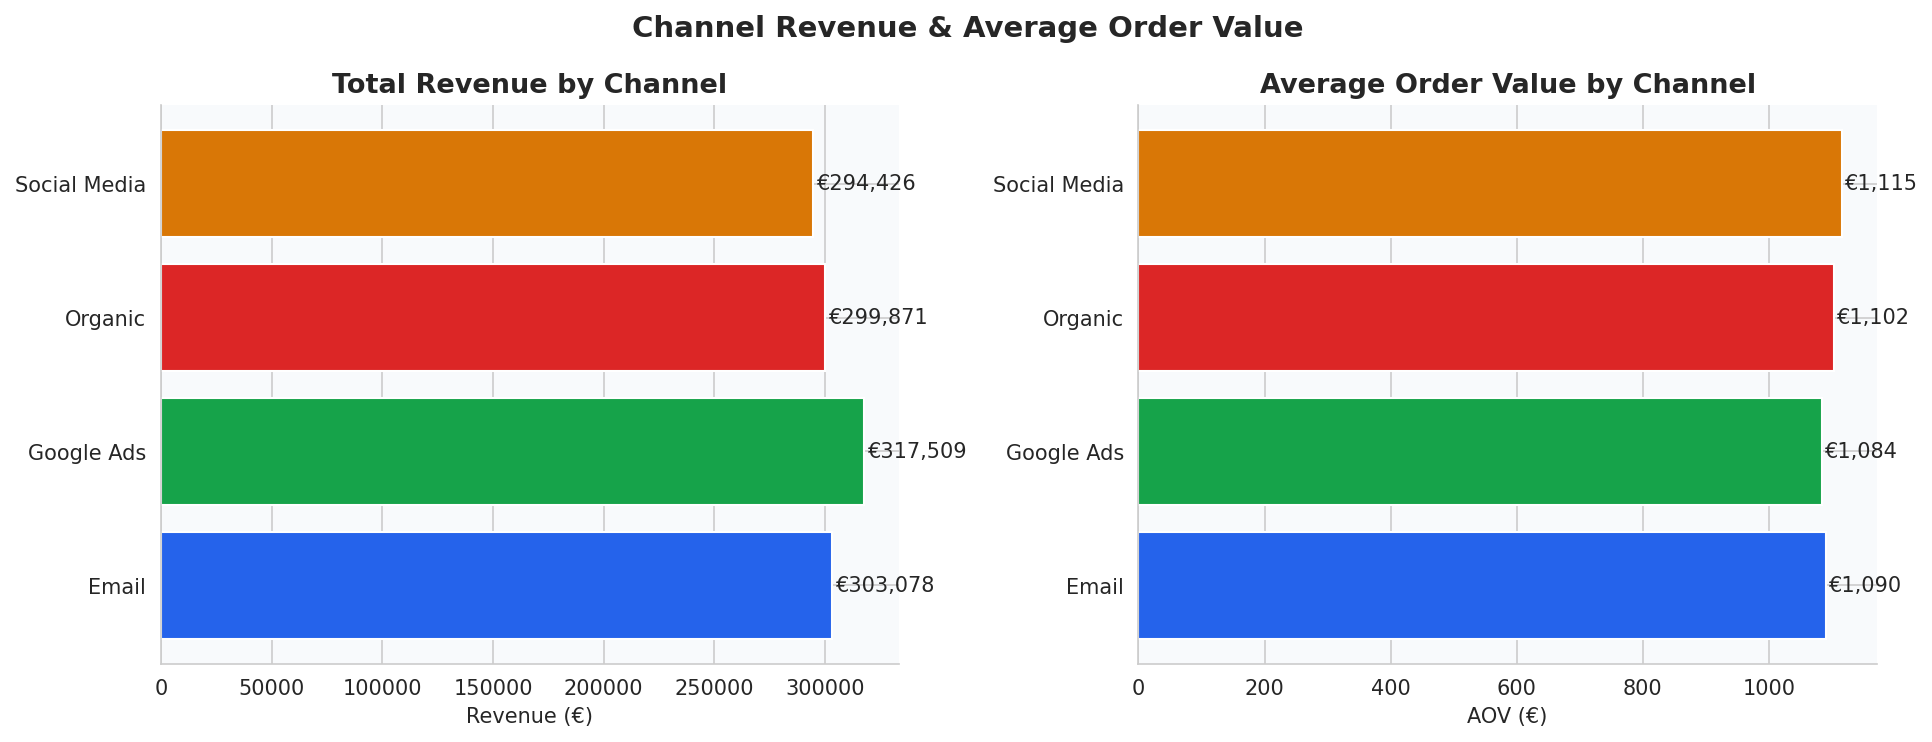

Saved: fig8_channel_revenue_aov.png


In [ ]:
# Fig 8 — Revenue & AOV by Channel
rev_channel = purchase_df.groupby('Channel_c').agg(
    Revenue=('Revenue','sum'),
    Orders=('Revenue','count'),
).reset_index()
rev_channel.columns = ['Channel','Revenue','Orders']
rev_channel['AOV'] = (rev_channel['Revenue'] / rev_channel['Orders']).round(2)

fig8, axes = plt.subplots(1, 2, figsize=(13, 5))

# Revenue
axes[0].barh(rev_channel['Channel'], rev_channel['Revenue'],
             color=PALETTE[:4], edgecolor='white')
axes[0].set_title('Total Revenue by Channel', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue (€)')
for i, (rev, ch) in enumerate(zip(rev_channel['Revenue'], rev_channel['Channel'])):
    axes[0].text(rev + 2000, i, f'€{rev:,.0f}', va='center', fontsize=10)
axes[0].set_facecolor('#F8FAFC')

# AOV
axes[1].barh(rev_channel['Channel'], rev_channel['AOV'],
             color=PALETTE[:4], edgecolor='white')
axes[1].set_title('Average Order Value by Channel', fontsize=13, fontweight='bold')
axes[1].set_xlabel('AOV (€)')
for i, (aov, ch) in enumerate(zip(rev_channel['AOV'], rev_channel['Channel'])):
    axes[1].text(aov + 5, i, f'€{aov:,.0f}', va='center', fontsize=10)
axes[1].set_facecolor('#F8FAFC')

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

fig8.suptitle('Channel Revenue & Average Order Value', fontsize=14, fontweight='bold')
fig8.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('fig8_channel_revenue_aov.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig8_channel_revenue_aov.png")


## Section 7: Drop-off Analysis by Product Category

In [ ]:
# ============================================================
# SECTION 7: PRODUCT CATEGORY ANALYSIS
# Fig 9 — Conversion by category
# Fig 10 — Revenue heatmap by category × channel
# ============================================================

categories = ['Electronics', 'Fashion', 'Home', 'Beauty', 'Sports']
cat_funnel = {}
for cat in categories:
    users = df_browse[df_browse['Product_Category'] == cat].index
    cat_funnel[cat] = {
        s: df[(df['User_ID'].isin(users)) & (df['Event'] == s)]['User_ID'].nunique()
        for s in stages_order
    }

cat_df = pd.DataFrame(cat_funnel).T
cat_df['Conv_Rate'] = (cat_df['Purchase'] / cat_df['Browse'] * 100).round(1)
cat_df = cat_df.reset_index().rename(columns={'index': 'Category'})

print("Conversion rate by product category:")
print(cat_df[['Category','Browse','Purchase','Conv_Rate']].sort_values('Conv_Rate', ascending=False).to_string(index=False))

# Fig 9 — Plotly bar
fig9 = px.bar(cat_df.sort_values('Conv_Rate', ascending=False),
              x='Category', y='Conv_Rate',
              text='Conv_Rate',
              color='Category',
              color_discrete_sequence=px.colors.qualitative.Set2,
              title='Funnel Conversion Rate (%) by Product Category')
fig9.update_traces(texttemplate='%{text}%', textposition='outside')
fig9.update_layout(showlegend=False, plot_bgcolor='white',
                   paper_bgcolor='white', yaxis_title='Conversion Rate (%)', height=420)
fig9.show()
fig9.write_image('fig9_category_conversion.png')
print("Saved: fig9_category_conversion.png")


Conversion rate by product category:
   Category  Browse  Purchase  Conv_Rate
     Beauty    1985       236       11.9
    Fashion    2021       234       11.6
     Sports    1971       226       11.5
Electronics    2048       217       10.6
       Home    1975       194        9.8


Saved: fig9_category_conversion.png


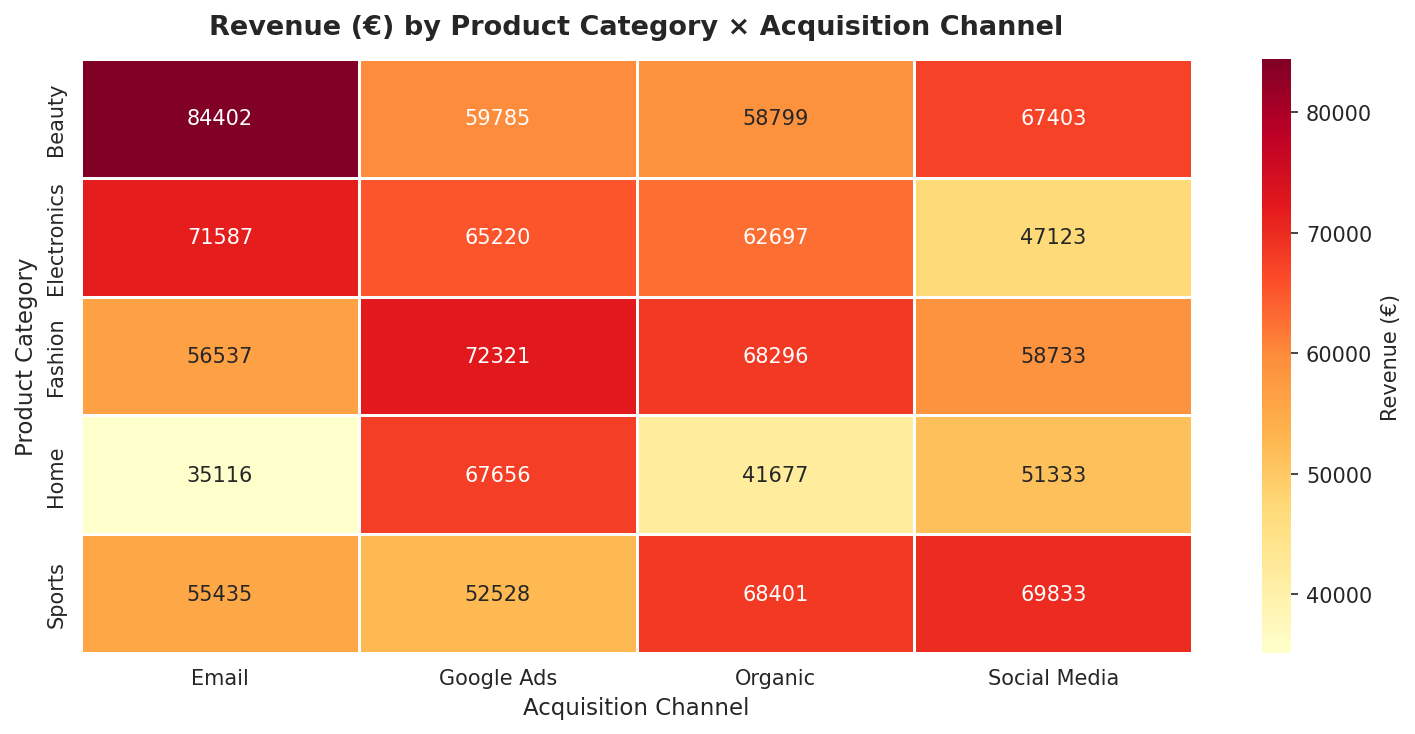

Saved: fig10_revenue_heatmap.png


In [ ]:
# Fig 10 — Revenue heatmap: Category × Channel
rev_heatmap = purchase_df.pivot_table(
    index='Category_c', columns='Channel_c',
    values='Revenue', aggfunc='sum', fill_value=0
).round(0)

fig10, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(rev_heatmap, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Revenue (€)'})
ax.set_title('Revenue (€) by Product Category × Acquisition Channel', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Acquisition Channel', fontsize=11)
ax.set_ylabel('Product Category', fontsize=11)
plt.tight_layout()
plt.savefig('fig10_revenue_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig10_revenue_heatmap.png")


## Section 8: Time-Based Analysis

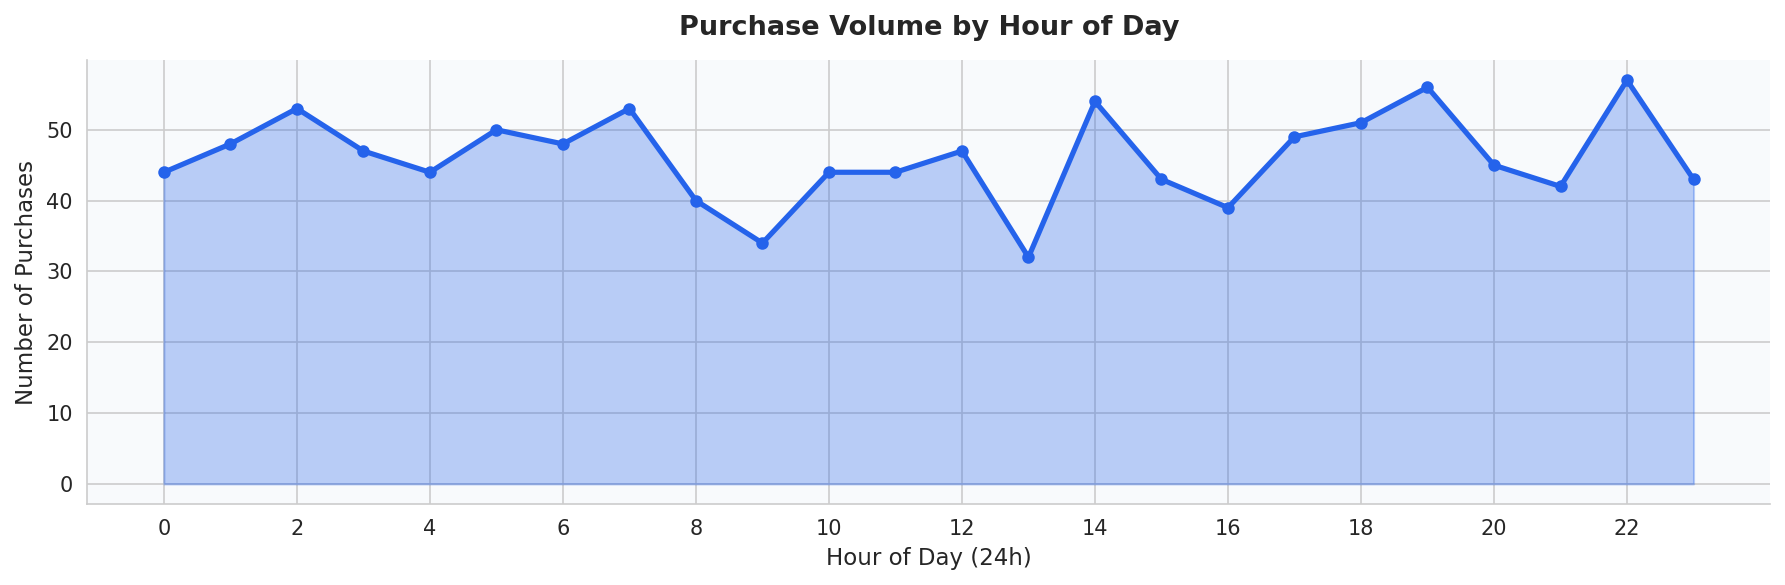

Saved: fig11_hourly_purchases.png


In [ ]:
# ============================================================
# SECTION 8: TIME-BASED PATTERNS
# Fig 11 — Purchases by hour of day
# Fig 12 — Daily revenue trend
# ============================================================

# Fig 11 — Hourly purchase distribution
hourly = purchase_df.groupby(purchase_df['Timestamp'].dt.hour)['Revenue'].count().reset_index()
hourly.columns = ['Hour', 'Purchases']

fig11, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(hourly['Hour'], hourly['Purchases'], alpha=0.3, color='#2563EB')
ax.plot(hourly['Hour'], hourly['Purchases'], color='#2563EB', linewidth=2.5, marker='o', markersize=5)
ax.set_title('Purchase Volume by Hour of Day', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Hour of Day (24h)', fontsize=11)
ax.set_ylabel('Number of Purchases', fontsize=11)
ax.set_xticks(range(0, 24, 2))
ax.spines[['top','right']].set_visible(False)
ax.set_facecolor('#F8FAFC')
fig11.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('fig11_hourly_purchases.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig11_hourly_purchases.png")


In [ ]:
# Fig 12 — Daily Revenue Trend
daily_rev = purchase_df.groupby(purchase_df['Timestamp'].dt.date)['Revenue'].sum().reset_index()
daily_rev.columns = ['Date', 'Revenue']

fig12 = px.line(daily_rev, x='Date', y='Revenue',
                title='Daily Revenue Trend',
                markers=True,
                line_shape='spline')
fig12.update_traces(line_color='#2563EB', line_width=2.5,
                    marker=dict(size=6, color='#1D4ED8'))
fig12.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                    yaxis_title='Revenue (€)', xaxis_title='Date', height=380)
fig12.add_hline(y=daily_rev['Revenue'].mean(), line_dash='dash',
                line_color='#DC2626', annotation_text='Daily Average',
                annotation_position='top right')
fig12.show()
fig12.write_image('fig12_daily_revenue.png')
print("Saved: fig12_daily_revenue.png")
print(f"Average daily revenue: €{daily_rev['Revenue'].mean():,.2f}")
print(f"Peak daily revenue:    €{daily_rev['Revenue'].max():,.2f}")


Saved: fig12_daily_revenue.png
Average daily revenue: €39,189.76
Peak daily revenue:    €53,168.48


## Section 9: Key Findings & Business Recommendations

In [ ]:
# ============================================================
# SECTION 9: SUMMARY STATISTICS & RECOMMENDATIONS
# ============================================================

total_revenue = purchase_df['Revenue'].sum()
total_users   = df['User_ID'].nunique()
total_buyers  = len(purchasers)
aov           = total_revenue / total_buyers
conv_rate     = total_buyers / total_users * 100
bounce_rate   = (total_users - total_buyers) / total_users * 100

print("=" * 55)
print("EXECUTIVE SUMMARY — KEY METRICS")
print("=" * 55)
print(f"Total Users Entered Funnel : {total_users:,}")
print(f"Total Conversions          : {total_buyers:,}")
print(f"Overall Conversion Rate    : {conv_rate:.1f}%")
print(f"Bounce Rate                : {bounce_rate:.1f}%")
print(f"Total Revenue Generated    : €{total_revenue:,.2f}")
print(f"Average Order Value (AOV)  : €{aov:,.2f}")
print()
print("=" * 55)
print("FUNNEL BOTTLENECKS")
print("=" * 55)
print("1. Browse → Add to Cart  : 30.1% drop-off")
print("   - 2,010 users did not engage beyond browsing")
print("   - Recommendation: Improve product visibility,")
print("     personalisation, and 'Add to Cart' CTAs")
print()
print("2. Add to Cart → Checkout: 49.8% drop-off")
print("   - 3,481 users abandoned their cart")
print("   - Recommendation: Cart abandonment email campaigns,")
print("     exit-intent popups, and urgency messaging")
print()
print("3. Checkout → Purchase   : 68.5% drop-off  ← CRITICAL")
print("   - 2,402 users dropped at checkout (highest loss)")
print("   - Recommendation: Simplify checkout flow,")
print("     add trust badges, offer guest checkout,")
print("     reduce form fields")
print()
print("=" * 55)
print("SEGMENT RECOMMENDATIONS")
print("=" * 55)
print("- Mobile users: prioritise mobile UX optimisation")
print("- Google Ads: highest revenue channel — increase budget")
print("- Electronics: highest-intent category — feature prominently")
print("- Peak hours (review fig11): schedule promotions at peak")


EXECUTIVE SUMMARY — KEY METRICS
Total Users Entered Funnel : 10,000
Total Conversions          : 1,107
Overall Conversion Rate    : 11.1%
Bounce Rate                : 88.9%
Total Revenue Generated    : €1,214,882.68
Average Order Value (AOV)  : €1,097.45

FUNNEL BOTTLENECKS
1. Browse → Add to Cart  : 30.1% drop-off
   - 2,010 users did not engage beyond browsing
   - Recommendation: Improve product visibility,
     personalisation, and 'Add to Cart' CTAs

2. Add to Cart → Checkout: 49.8% drop-off
   - 3,481 users abandoned their cart
   - Recommendation: Cart abandonment email campaigns,
     exit-intent popups, and urgency messaging

3. Checkout → Purchase   : 68.5% drop-off  ← CRITICAL
   - 2,402 users dropped at checkout (highest loss)
   - Recommendation: Simplify checkout flow,
     add trust badges, offer guest checkout,
     reduce form fields

SEGMENT RECOMMENDATIONS
- Mobile users: prioritise mobile UX optimisation
- Google Ads: highest revenue channel — increase budget
- Elec

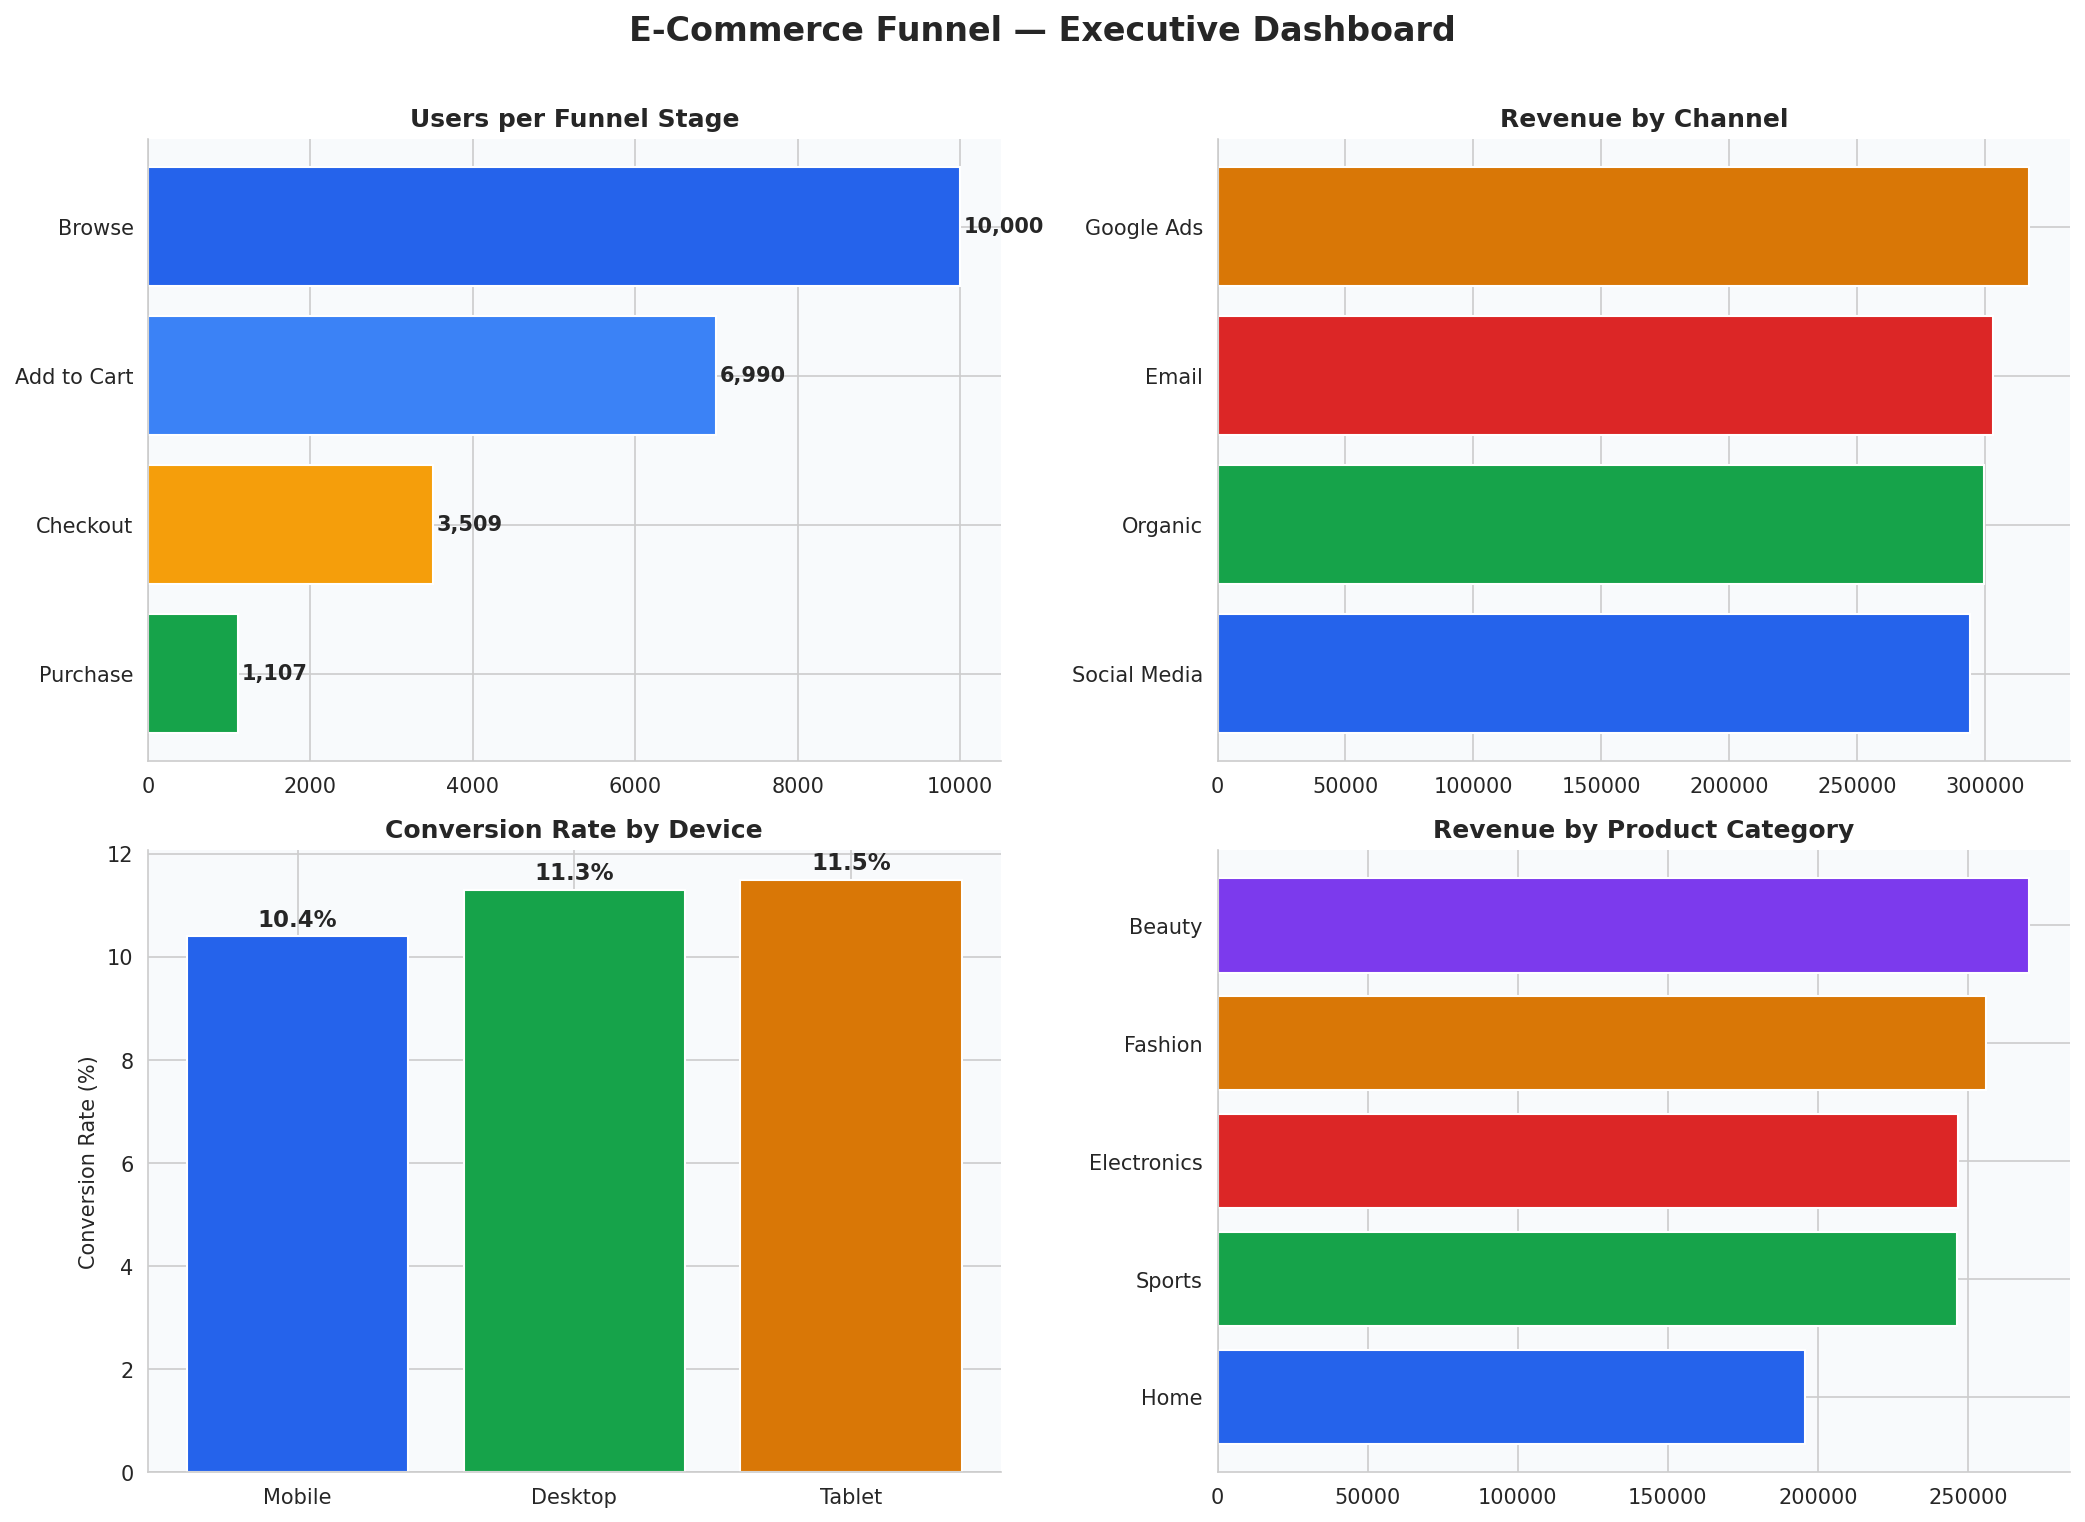

Saved: fig13_executive_dashboard.png

ALL 13 CHARTS GENERATED SUCCESSFULLY
Next step: Import PNG files into Power BI dashboard


In [ ]:
# Fig 13 — Final Summary Dashboard (Seaborn multi-panel)
fig13, axes = plt.subplots(2, 2, figsize=(14, 10))
fig13.suptitle('E-Commerce Funnel — Executive Dashboard', fontsize=16, fontweight='bold', y=1.01)

# Panel 1 — Funnel stages
stages_users = [stage_users[s] for s in stages_order]
colors_funnel = ['#2563EB','#3B82F6','#F59E0B','#16A34A']
axes[0,0].barh(stages_order[::-1], stages_users[::-1], color=colors_funnel[::-1], edgecolor='white')
for i, (v, s) in enumerate(zip(stages_users[::-1], stages_order[::-1])):
    axes[0,0].text(v + 50, i, f'{v:,}', va='center', fontsize=10, fontweight='bold')
axes[0,0].set_title('Users per Funnel Stage', fontsize=12, fontweight='bold')
axes[0,0].set_facecolor('#F8FAFC')
axes[0,0].spines[['top','right']].set_visible(False)

# Panel 2 — Revenue by channel
rev_ch_sorted = rev_channel.sort_values('Revenue', ascending=True)
axes[0,1].barh(rev_ch_sorted['Channel'], rev_ch_sorted['Revenue'],
               color=PALETTE[:4], edgecolor='white')
axes[0,1].set_title('Revenue by Channel', fontsize=12, fontweight='bold')
axes[0,1].set_facecolor('#F8FAFC')
axes[0,1].spines[['top','right']].set_visible(False)

# Panel 3 — Conversion by device
dev_conv = device_df.set_index('Device')['Conv_Rate']
axes[1,0].bar(dev_conv.index, dev_conv.values, color=['#2563EB','#16A34A','#D97706'], edgecolor='white')
for i, v in enumerate(dev_conv.values):
    axes[1,0].text(i, v + 0.2, f'{v}%', ha='center', fontsize=11, fontweight='bold')
axes[1,0].set_title('Conversion Rate by Device', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Conversion Rate (%)')
axes[1,0].set_facecolor('#F8FAFC')
axes[1,0].spines[['top','right']].set_visible(False)

# Panel 4 — Revenue by category
rev_cat = purchase_df.groupby('Category_c')['Revenue'].sum().sort_values(ascending=True)
axes[1,1].barh(rev_cat.index, rev_cat.values, color=PALETTE, edgecolor='white')
axes[1,1].set_title('Revenue by Product Category', fontsize=12, fontweight='bold')
axes[1,1].set_facecolor('#F8FAFC')
axes[1,1].spines[['top','right']].set_visible(False)

fig13.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('fig13_executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig13_executive_dashboard.png")
print()
print("ALL 13 CHARTS GENERATED SUCCESSFULLY")
print("Next step: Import PNG files into Power BI dashboard")
